# Semantic Segmentation of Road Images with U-NET


**Acknowledgement:** This notebook is partly based on [https://github.com/hossamemamo/KITTI-Road-Segmentation-UNET](https://github.com/hossamemamo/KITTI-Road-Segmentation-UNET)

In this notebook we implement **semantic segmentation** on the KITTI Road dataset using **U-NET** built from scratch.


In [1]:
#imports
import numpy as np
import pandas as pd
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms.functional as TF
from tqdm import tqdm

import matplotlib.pyplot as plt
%matplotlib inline

from PIL import Image
import math

import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

from collections import defaultdict


# 1. Loading and Preparing the KITTI Road Dataset

**TODO:** Download the KITTI road dataset from here: https://bwsyncandshare.kit.edu/s/972P9wnwTaeY6CR and place it in a folder 'data' in your working directory. Unzip the data and check (potentially adapt) the paths below.

**NOTE:** The original data can alternatively be found at http://www.cvlibs.net/download.php?file=data_road.zip. 

In [2]:
# Define paths
data_path = './data/data_road/training/' 

mask_path = data_path + 'gt_image_2/'
img_path = data_path + 'image_2/'   
test_path = data_path + 'testing/'

In [3]:
# Number of training examples
train_set_size = int(len(os.listdir(img_path)) * 0.8)
print(f"Number of Training Examples: {train_set_size}")

validation_set_size = int(len(os.listdir(img_path)) * 0.1)
print(f"Number of Validation Examples: {validation_set_size}")

test_set_size = int(len(os.listdir(img_path)) - train_set_size - validation_set_size)
print(f"Number of Testing Examples: {test_set_size}")

Number of Training Examples: 231
Number of Validation Examples: 28
Number of Testing Examples: 30


In [4]:
# Function to load images from a directory and resize them to 128x128
def loadImages(path,mask=False):
    result = [] 
    images = os.listdir(path)
    if mask==True:
        images = [entry for entry in images if "road" in entry]

    images=sorted(images)
    
    print(images)
    for image in images:
        im = Image.open(os.path.join(path, image))
        resized_im = im.resize((128, 128))
        res = np.asarray(resized_im)
        result.append(res)
    return np.array(result)

In [5]:
# Utility to display a number of images
def show_images(images, num_images_to_show):
    fig = plt.figure()
    for i in range(1,num_images_to_show+1):
        fig.add_subplot(1,num_images_to_show,i)
        img = images[i-1,:]
        plt.imshow(img)

Let's load some images, display them and show some masks as well:

['um_000000.png', 'um_000001.png', 'um_000002.png', 'um_000003.png', 'um_000004.png', 'um_000005.png', 'um_000006.png', 'um_000007.png', 'um_000008.png', 'um_000009.png', 'um_000010.png', 'um_000011.png', 'um_000012.png', 'um_000013.png', 'um_000014.png', 'um_000015.png', 'um_000016.png', 'um_000017.png', 'um_000018.png', 'um_000019.png', 'um_000020.png', 'um_000021.png', 'um_000022.png', 'um_000023.png', 'um_000024.png', 'um_000025.png', 'um_000026.png', 'um_000027.png', 'um_000028.png', 'um_000029.png', 'um_000030.png', 'um_000031.png', 'um_000032.png', 'um_000033.png', 'um_000034.png', 'um_000035.png', 'um_000036.png', 'um_000037.png', 'um_000038.png', 'um_000039.png', 'um_000040.png', 'um_000041.png', 'um_000042.png', 'um_000043.png', 'um_000044.png', 'um_000045.png', 'um_000046.png', 'um_000047.png', 'um_000048.png', 'um_000049.png', 'um_000050.png', 'um_000051.png', 'um_000052.png', 'um_000053.png', 'um_000054.png', 'um_000055.png', 'um_000056.png', 'um_000057.png', 'um_000058.pn

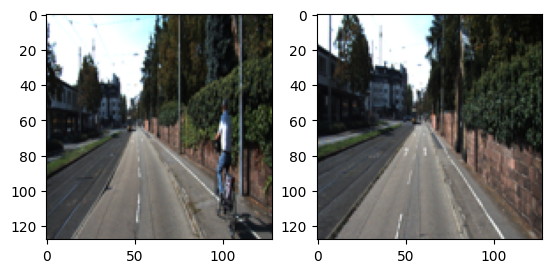

In [6]:
# Load images and show some samples
data=loadImages(img_path,mask=False)
show_images(data,2)

['um_road_000000.png', 'um_road_000001.png', 'um_road_000002.png', 'um_road_000003.png', 'um_road_000004.png', 'um_road_000005.png', 'um_road_000006.png', 'um_road_000007.png', 'um_road_000008.png', 'um_road_000009.png', 'um_road_000010.png', 'um_road_000011.png', 'um_road_000012.png', 'um_road_000013.png', 'um_road_000014.png', 'um_road_000015.png', 'um_road_000016.png', 'um_road_000017.png', 'um_road_000018.png', 'um_road_000019.png', 'um_road_000020.png', 'um_road_000021.png', 'um_road_000022.png', 'um_road_000023.png', 'um_road_000024.png', 'um_road_000025.png', 'um_road_000026.png', 'um_road_000027.png', 'um_road_000028.png', 'um_road_000029.png', 'um_road_000030.png', 'um_road_000031.png', 'um_road_000032.png', 'um_road_000033.png', 'um_road_000034.png', 'um_road_000035.png', 'um_road_000036.png', 'um_road_000037.png', 'um_road_000038.png', 'um_road_000039.png', 'um_road_000040.png', 'um_road_000041.png', 'um_road_000042.png', 'um_road_000043.png', 'um_road_000044.png', 'um_road_

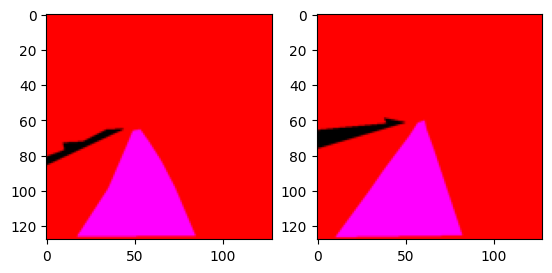

In [7]:
# Load masks and show some samples
true_mask=loadImages(mask_path,mask=True)
show_images(true_mask,2)

Note that the masks contain several classes, but we only need a binary mask for road pixels. So we convert the existing masks:

In [8]:
def convert_to_binary_mask(true_mask):
    noMasks=len(true_mask)
    for i in range(noMasks):
        #convert all masks to just binary masks (road and no road)
        road_label =np.array([255, 0, 255])
        cond=np.all(true_mask[i] == road_label, axis = 2)
        true_mask[i]=true_mask[i] * cond[..., np.newaxis]

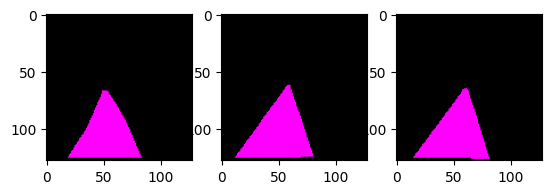

In [9]:
convert_to_binary_mask(true_mask)
show_images(true_mask,3)

Now we convert the masks from RGB to grayscale. We use weighting factors according to the luminosity method, i.e., green is weighted stronger than red and blue, because the human eye is more sensitive to green light:

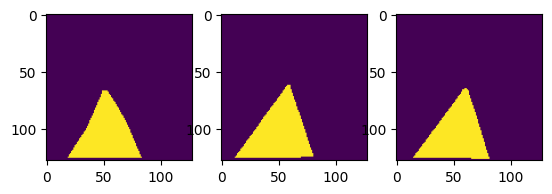

In [10]:
# Convert masks to grayscale
true_mask=np.dot(true_mask[..., :3], [0.2989, 0.5870, 0.1140])
true_mask=np.expand_dims(true_mask, axis=-1)
show_images(true_mask, 3)

In [11]:
# Convert grayscale masks to binary masks
true_mask[true_mask != 0.0]=1.0

In [12]:
# Normalize image data to [0, 1]
data  = data / 255.0

Next, we define a **data augmentation** pipeline to increase the number of training images and make our results more robust. We use the **albumentations** package for this:

In [13]:
# Data augmentation pipeline
augmentation_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.5,border_mode=cv2.BORDER_CONSTANT),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2, p=0.5),
    A.RGBShift(r_shift_limit=1, g_shift_limit=1, b_shift_limit=1, p=0.5),
])

In [14]:
data=data.astype(np.float32)
true_mask=true_mask.astype(np.float32)

In [15]:
test_aug=augmentation_pipeline(image=data[5], mask=true_mask[5])
test_example=test_aug["image"]
test_mask=test_aug["mask"]

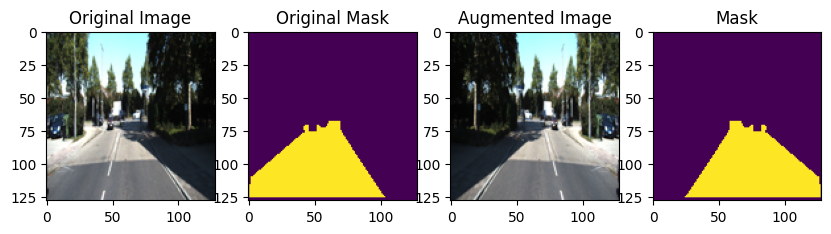

In [16]:
# Show the original and augmented images side by side
fig, ax = plt.subplots(1, 4, figsize=(10, 5))
ax[0].imshow(data[5])
ax[0].set_title("Original Image")

ax[1].imshow(true_mask[5])
ax[1].set_title("Original Mask")

ax[2].imshow(test_example)
ax[2].set_title("Augmented Image")

ax[3].imshow(test_mask)
ax[3].set_title("Mask")

plt.show()

In [17]:
# Augment the entire dataset
n = 10  # Number of augmentations per image
for i in range(len(data)):
    for j in range(n):
        image = data[i]
        mask = true_mask[i]
        # Apply the augmentation pipeline
        augmented = augmentation_pipeline(image=image, mask=mask)

        image_augmented = augmented["image"]
        mask_augmented = augmented["mask"]
        data = np.vstack((data, image_augmented[np.newaxis,...]))
        true_mask = np.vstack((true_mask, mask_augmented[np.newaxis,...]))

In [18]:
# Number of training examples after augmentation
train_set_size = int(len(data) * 0.8)
print(f"Number of Training Examples: {train_set_size}")

validation_set_size = int(len(data) * 0.1)
print(f"Number of Validation Examples: {validation_set_size}")

test_set_size = len(data) - train_set_size - validation_set_size
print(f"Number of Testing Examples: {test_set_size}")

Number of Training Examples: 2543
Number of Validation Examples: 317
Number of Testing Examples: 319


In [19]:
# first part of the data will be used for testing
X_test=data[:test_set_size].transpose((0, 3, 1, 2))
y_test=true_mask[:test_set_size].transpose((0, 3, 1, 2))
print(f'test set size: {X_test.shape}')

#rest of the data will be agumented and shuffled for training
data=data[test_set_size:]
true_mask=true_mask[test_set_size:]

# Shuffle the indices
shuffled_indices = np.random.permutation(len(data))

# Use the shuffled indices to shuffle both arrays
shuffled_data = data[shuffled_indices]
shuffled_masks = true_mask[shuffled_indices]


test set size: (319, 3, 128, 128)


In [20]:
# train validation split
X_train=shuffled_data[:train_set_size].transpose((0, 3, 1, 2))
y_train=shuffled_masks[:train_set_size].transpose((0, 3, 1, 2))
print(f'training set size: {X_train.shape}')

X_val=shuffled_data[train_set_size:train_set_size+validation_set_size].transpose((0, 3, 1, 2))
y_val=shuffled_masks[train_set_size:train_set_size+validation_set_size].transpose((0, 3, 1, 2))
print(f'validation set size: {X_val.shape}')

training set size: (2543, 3, 128, 128)
validation set size: (317, 3, 128, 128)


In [21]:
# Define a custom Dataset class
from torch.utils.data import Dataset, DataLoader

class ImageDataset(Dataset):
    def __init__(self, imgs,mask):
        self.imgs=imgs
        self.mask=mask

    def __len__(self):
        return len(self.imgs)

    def get_batch_imgs(self, idx):
        # Fetch a batch of inputs
        return self.imgs[idx]
    
    def get_batch_masks(self, idx):
    # Fetch a batch of inputs
        return self.mask[idx]

    
    def __getitem__(self, index):
        imgs=self.get_batch_imgs(index)
        masks=self.get_batch_masks(index)
        return imgs,masks

In [22]:
# Create dataset instances
train_dataset = ImageDataset(X_train,y_train)
val_dataset = ImageDataset(X_val, y_val)
test_dataset = ImageDataset(X_test, y_test)

# Create a DataLoader from the dataset
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader=DataLoader(val_dataset, batch_size=32, shuffle=True)
test_dataloader=DataLoader(test_dataset, batch_size=32, shuffle=False)

# 2. Building the U-NET Model Architecture (From Scratch)

Now that we have cleaned up and augmented our data, we can define our U-NET architecture. Remember that U-NET consists of a contracting path to capture context and a symmetric expanding path that enables precise localization:

<img src="images/UNET.png" />

In [23]:
# Since there are many double convolutions in this architecture, we create a class to write less redundant code
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv,self).__init__() # essential to use nn.Module
        # bias is set to False because we apply batch norm later so it's unnecessary
        self.dconv=nn.Sequential(nn.Conv2d(in_channels,out_channels,kernel_size=3,stride=1,padding=1,bias=False),
                                 nn.BatchNorm2d(out_channels),
                                 nn.ReLU(inplace=True),
                                 nn.Conv2d(out_channels,out_channels,kernel_size=3,stride=1,padding=1,bias=False),
                                 nn.BatchNorm2d(out_channels),
                                 nn.ReLU(inplace=True),
        )
        
    def forward(self, x):
        return self.dconv(x)
    
# Define the UNET architecture
class UNET(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super(UNET,self).__init__()
        
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Down part of UNET
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # Up part of UNET
        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2)) # upsampling
            self.ups.append(DoubleConv(feature*2, feature))

        self.left_over = DoubleConv(features[-1], features[-1]*2) # this represents the last part which starts the UP phase
        
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1) # output segmentation  map

    def forward(self,x):
        skip_connections = []
        
        # starting the down phase will iterate through the downs module
        for layer in self.downs:
            x=layer(x)
            skip_connections.append(x) # save this to feed it later
            x=self.pool(x)
        
        # to move from left to right we pass through the "left_over"
        x=self.left_over(x)
        skip_connections=skip_connections[::-1]
        for idx in range(0,len(self.ups), 2): # our goal it so feed to transposed conv and add skipped connection. ups has 2 steps in each so we will make it a step of 2:
            
            sc=skip_connections[idx//2]
            x=self.ups[idx](x) # step 1
            
            if x.shape != sc.shape:
                x = TF.resize(x, size=sc.shape[2:])

            concat_skip = torch.cat((sc, x), dim=1) # concatenation step
            x = self.ups[idx+1](concat_skip) # step 2


        return torch.sigmoid(self.final_conv(x)) # last step in forward            
        

# 3. Training

Before we can start our training, we need to define a loss function. **IOU (Intersection over Union)** loss is a valuable tool for optimizing segmentation models. It measures the overlap between predicted and ground truth segmentations, encouraging accurate boundary capture. By minimizing the IOU loss during training, models generate more precise segmentations.

**Note:** Binary cross-entropy loss is suitable for pixel-wise classification tasks, while IOU loss is beneficial for evaluating and optimizing segmentation models that require accurate boundary capture. Many segmentation models therefore combine both loss functions to leverage their strengths.

<img src="images/IOU.png" />

In [24]:
# Define IoU Loss
class IoULoss(nn.Module):
    def __init__(self):
        super(IoULoss, self).__init__()
        self.eps = 1e-6 # small constant to avoid division by zero

    def forward(self, y_pred, y_true):
        # Flatten the input tensors
        y_pred = y_pred.view(-1)        
        y_true = y_true.view(-1)
        # Calculate the confusion matrix
        intersection = (y_pred * y_true).sum()
        union = y_pred.sum() + y_true.sum() - intersection

        # Calculate the IoU and return the complement as the loss
        iou = intersection / (union + self.eps)
        return 1 - iou


In [25]:
# Train settings
EPOCHS=50 # increase for improved results
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
loss_fn = IoULoss().to(DEVICE)
LEARNING_RATE=1e-3

model = UNET(in_channels=3, out_channels=1).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)


Using device: cuda:0


**TODO:** Implement and run the training! Store the training and validation losses for each epoch for later visualization. Save your best model under the name `best_u-net_state.pth`.

In [26]:
# YOUR CODE HERE
# Training function for one epoch
def train_epoch(model, data_loader, loss_fn, optimizer, device):
    model = model.train()

    losses = []

    for train_input, train_mask in tqdm(data_loader):
        train_mask = train_mask.to(device)
        train_input=train_input.to(device)
        
        outputs=model(train_input.float())
        
        loss = loss_fn(outputs.float(), train_mask.float())
        
        losses.append(loss.item())

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    return np.mean(losses)

In [27]:
# YOUR CODE HERE
# Evaluation function for one epoch
def eval_model(model, data_loader, loss_fn, device):
    model = model.eval()

    losses = []

    with torch.no_grad():
        for val_input, val_mask in data_loader:
            
            val_mask = val_mask.to(device)
            val_input=val_input.to(device)
            outputs=model(val_input.float())
           
            loss = loss_fn(outputs.float(), val_mask.float())
            losses.append(loss.item())

    return np.mean(losses)

In [28]:
# YOUR CODE HERE
# Define a history dictionary to store training and validation losses
history = defaultdict(list)

# Training loop
loss=math.inf
for epoch in range(EPOCHS):

    train_loss = train_epoch(model, train_dataloader, loss_fn, optimizer, DEVICE)
    
    val_loss = eval_model(model, val_dataloader, loss_fn, DEVICE)
    
    
    if epoch%5 == 0 :
        print(f'Epoch {epoch + 1}/{EPOCHS}')
        print('-' * 10)
        print(f'Train loss {train_loss}')
        print(f'Valid loss {val_loss}')
        print()
        
    if val_loss < loss:
        torch.save(model.state_dict(), 'best_u-net_state.pth')
        loss = val_loss

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)


  0%|                                                                                                         | 0/80 [00:00<?, ?it/s]


  1%|█▏                                                                                               | 1/80 [00:00<00:25,  3.14it/s]


  4%|███▋                                                                                             | 3/80 [00:00<00:10,  7.30it/s]


  5%|████▊                                                                                            | 4/80 [00:00<00:09,  7.95it/s]


  6%|██████                                                                                           | 5/80 [00:00<00:08,  8.42it/s]

...


 95%|███████████████████████████████████████████████████████████████████████████████████████████▏    | 76/80 [00:08<00:00,  9.38it/s]


 96%|████████████████████████████████████████████████████████████████████████████████████████████▍   | 77/80 [00:08<00:00,  9.37it/s]


 98%|█████████████████████████████████████████████████████████████████████████████████████████████▌  | 78/80 [00:08<00:00,  9.37it/s]


 99%|██████████████████████████████████████████████████████████████████████████████████████████████▊ | 79/80 [00:08<00:00,  9.38it/s]


100%|████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:08<00:00,  9.42it/s]

# 4. Evaluation

Now let's see how our trained model performs! First, we load the best model and take a look at the training and validation losses:

In [29]:
# Load the best model state
model.load_state_dict(torch.load('best_u-net_state.pth'))

<All keys matched successfully>

**TODO:** Plot training and validation loss curves. 

**HINT:** The history dictionary contains the training and validation losses for each epoch.

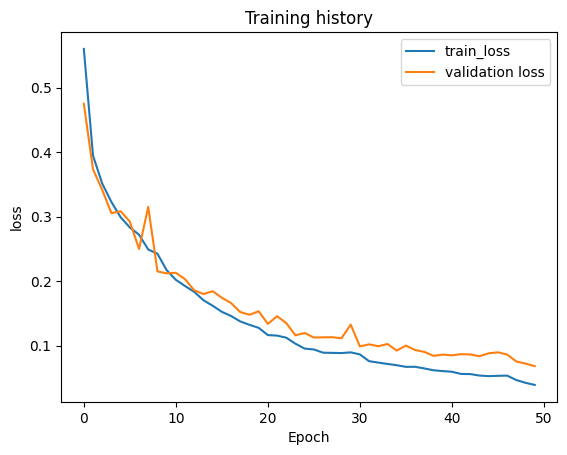

In [ ]:
# YOUR CODE HERE
# Plot training and validation loss
plt.plot(history['train_loss'], label='train_loss')
plt.plot(history['val_loss'], label='validation loss')

plt.title('Training history')
plt.ylabel('loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

**TODO:** How do you interpret the loss curves?

**ANSWER:** Both training and validation losses decrease very nicely and are in a similar range, so the training converges; the slightly larger validation loss is a sign for mild overfitting, but not problematic. The loss curves have not reached a plateau yet, so we should keep training to further improve.

Let's take a look at the predicted segmentation masks:

In [31]:
# Function to get predicted masks and average loss on a dataset
def get_predicted_masks(model, data_loader, loss_fn, device):
    model = model.eval()

    masks=[]
    losses = []

    with torch.no_grad():
        for test_input, test_mask in data_loader:
            
            test_mask = test_mask.to(device)
            test_input=test_input.to(device)
            outputs=model(test_input.float())
            
            masks.append(outputs.cpu().detach().numpy())
           
            loss = loss_fn(outputs.float(), test_mask.float())
            losses.append(loss.item())

    return np.mean(losses),masks


In [32]:
# Get predictions on the test set
loss,masks=get_predicted_masks(model,test_dataloader,loss_fn,DEVICE)

predicted_masks=np.array(masks[0])
for idx in range(1,len(masks)):
    predicted_masks=np.vstack((predicted_masks, masks[idx]))

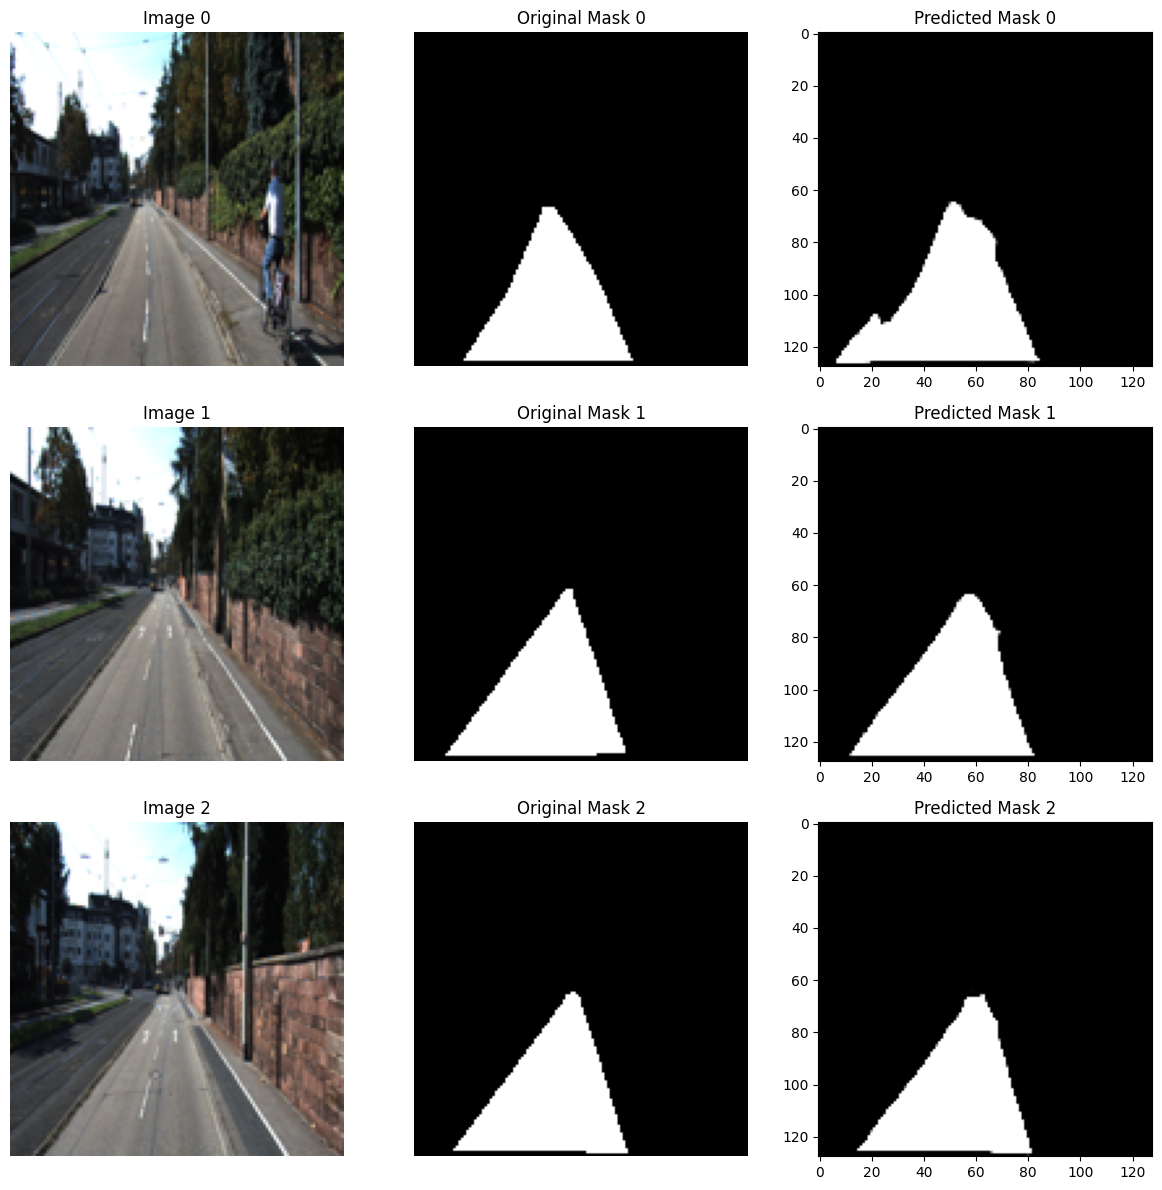

In [33]:
# Show 3 examples
fig, ax = plt.subplots(3, 3, figsize=(12, 12))

for i in range(3):
    # Original image
    ax[i, 0].imshow(X_test[i].transpose(1, 2, 0))
    ax[i, 0].set_title(f"Image {i}")
    ax[i, 0].axis("off")
    
    # Ground truth mask
    ax[i, 1].imshow(y_test[i].transpose(1, 2, 0), cmap="gray")
    ax[i, 1].set_title(f"Original Mask {i}")
    ax[i, 1].axis("off")
    
    # Predicted mask
    ax[i, 2].imshow(predicted_masks[i].transpose(1, 2, 0), cmap="gray")
    ax[i, 2].set_title(f"Predicted Mask {i}")
    
plt.tight_layout()
plt.show()

Not bad, the predicted masks capture the road surface quite well! To further improve, you can try training longer, adding a BCE loss component in addition to IoU, building a deeper U-Net or adding more regularization.